# Single-spectrum vs batch preprocessing debug

Compare what the batch fitter sees with raw data, optional background-frame
averages, and **grid PDF normalization** (see `normalize_curves_for_grid`).

**Key finding (package behaviour):** `BACKGROUND_FRAMES` is passed into
`run_bh_batch` but is **only** used for `check_background_flat` and
`scan_signal_frames` (noise level in the band image). It is **not** subtracted
from spectra. Per-spectrum preprocessing is `set_baseline_zero(True)`: subtract
the **minimum along the wavelength row** (after optional `dark_frame` cube subtraction).

Frame and channel indices are **0-based** (`Vis133M.spectrum` docstring).

In [ ]:
from pathlib import Path

FITS_FILE = Path("~/Dropbox/Experiments/2025-LHD-BH/133mORCA/193788.fits").expanduser()
SHOT = 193788
FRAME = 8
CHANNEL = 5

BACKGROUND_FRAMES = (0, 1, 2, 3)

# Match your batch YAML / notebook (wrong scale is a common single-vs-batch mismatch).
CW_NM = 431.91
SCALE = 0.1s
TIME_RANGE = (0.0, 10.0)
DARK_FRAME = None

SAVE_DEBUG_FIGURES = False
DEBUG_OUT = Path("debug_single_spectrum")

if SAVE_DEBUG_FIGURES:
    DEBUG_OUT.mkdir(parents=True, exist_ok=True)

## 1. Where `BACKGROUND_FRAMES` goes

- **Defined:** `run_bh_batch(..., background_frames=(0,1,2,3))` default in `workflows/batch_fit.py`.
- **YAML/CLI:** forwarded from config in `cli.py`.
- **Used:** `check_background_flat(vis, background_frames)` then `scan_signal_frames(..., background_frames=...)` — **only** if frames/channels are auto-selected.
- **Not used:** `Vis133M.spectrum` / `BHFitter._window_data` — no background subtraction there.

Run the next cell to print the exact tuple and compare to requested.

In [2]:
import numpy as np

from bh_molecule.workflows.signal_scan import _normalize_indices

requested = BACKGROUND_FRAMES
actual = tuple(_normalize_indices(BACKGROUND_FRAMES))
print(f"Requested BACKGROUND_FRAMES: {requested}")
print(f"Actual background frames used (signal scan / flat check): {actual}")
print("These indices are 0-based frame indices into the FITS cube.")

Requested BACKGROUND_FRAMES: (0, 1, 2, 3)
Actual background frames used (signal scan / flat check): (0, 1, 2, 3)
These indices are 0-based frame indices into the FITS cube.


In [3]:
if not FITS_FILE.is_file():
    raise FileNotFoundError(
        f"FITS not found: {FITS_FILE}\n"
        "Adjust FITS_FILE or run this notebook where data exist."
    )

In [4]:
import matplotlib.pyplot as plt

from bh_molecule.fit import BHFitter
from bh_molecule.physics import BHModel
from bh_molecule.workflows.batch_fit import prepare_vis_for_bh_batch
from bh_molecule.workflows.preprocessing import (
    mean_background_spectrum,
    subtract_background_from_row,
)
from bh_molecule.plotting.batch_fit_plots import normalize_curves_for_grid

# --- Path A: exactly what run_bh_batch uses before BHFitter ----------------
vis_batch = prepare_vis_for_bh_batch(
    FITS_FILE,
    cw=CW_NM,
    scale=SCALE,
    dark_frame=DARK_FRAME,
    time_range=TIME_RANGE,
)

# --- Path B: same instrument, no baseline_zero (raw scaled counts) ---------
from bh_molecule.instruments.vis133m import Vis133M

vis_raw = Vis133M.from_files(str(FITS_FILE), scale=SCALE)
vis_raw.apply_cw(cw_nm=float(CW_NM))
vis_raw.set_scale(float(SCALE))
if DARK_FRAME is not None:
    df = int(DARK_FRAME)
    vis_raw.cube = vis_raw.cube - vis_raw.cube[df][None, :, :]
vis_raw.set_baseline_zero(False)
vis_raw.set_time_linspace(*TIME_RANGE)

wl_raw, spec_raw = vis_raw.spectrum(FRAME, CHANNEL, zero_min=False)
wl_fit, spec_fit = vis_batch.spectrum(FRAME, CHANNEL)  # baseline_zero True

assert np.allclose(wl_raw, wl_fit), "Wavelength grid mismatch between paths"

# Background: mean over BACKGROUND_FRAMES in raw cube units, then scale (not done in package)
bg_row = mean_background_spectrum(vis_raw.cube, BACKGROUND_FRAMES, CHANNEL)
row_signal = vis_raw.cube[FRAME, CHANNEL].astype(float)
sub_counts = subtract_background_from_row(row_signal, bg_row)
spec_bg_sub = sub_counts * SCALE

nm_lo, nm_hi = 433.05, 433.90
mask = (wl_raw >= nm_lo) & (wl_raw <= nm_hi)

def stats(name, arr):
    a = np.asarray(arr, dtype=float)
    print(
        f"{name:28s} min={np.nanmin(a):.6g} max={np.nanmax(a):.6g} "
        f"median={np.median(a):.6g}"
    )

print(f"\nWavelength range (full channel): {float(wl_raw.min()):.4f} – {float(wl_raw.max()):.4f} nm")
print(f"Fit window used by BHFitter:    [{nm_lo}, {nm_hi}] nm\n")
stats("raw (scaled)", spec_raw)
stats("background mean (scaled)", bg_row * SCALE)
stats("signal − bg mean (scaled)", spec_bg_sub)
stats("batch path (min-sub row)", spec_fit)
stats("batch path windowed", spec_fit[mask])

model = BHModel()
fitr = BHFitter(vis=vis_batch, model=model)
try:
    res = fitr.fit(FRAME, CHANNEL, return_fit=True)
    ok = True
    err = None
except Exception as e:
    res = None
    ok = False
    err = repr(e)

if ok:
    x, y = res["x"], res["y"]
    yfit = res["yfit"]
    idx_dx = fitr.param_names.index("dx")
    print(f"\nFit OK. dx = {res['params'][idx_dx]:+.5f} nm")
    for n, v in zip(fitr.param_names, res["params"]):
        print(f"  {n} = {v:.6g}")
    resid = y - yfit
    print(
        f"Residuals: rms={np.sqrt(np.mean(resid**2)):.6g} "
        f"max|.|={np.max(np.abs(resid)):.6g}"
    )
else:
    print(f"\nFit failed: {err}")
    x = y = yfit = None


Wavelength range (full channel): 429.4641 – 434.3514 nm
Fit window used by BHFitter:    [433.05, 433.9] nm

raw (scaled)                 min=1881 max=7406 median=1976
background mean (scaled)     min=1881.75 max=1974.25 median=1915.5
signal − bg mean (scaled)    min=-24 max=5495.75 median=61.125
batch path (min-sub row)     min=0 max=5525 median=95
batch path windowed          min=0 max=721 median=93.5

Fit OK. dx = +0.02028 nm
  C = 10
  T_rot = 10000
  dx = 0.0202808
  w_inst = 0.0136131
  base = 10
  I_R7 = 1
  I_R8 = 1
Residuals: rms=179.243 max|.|=691.61


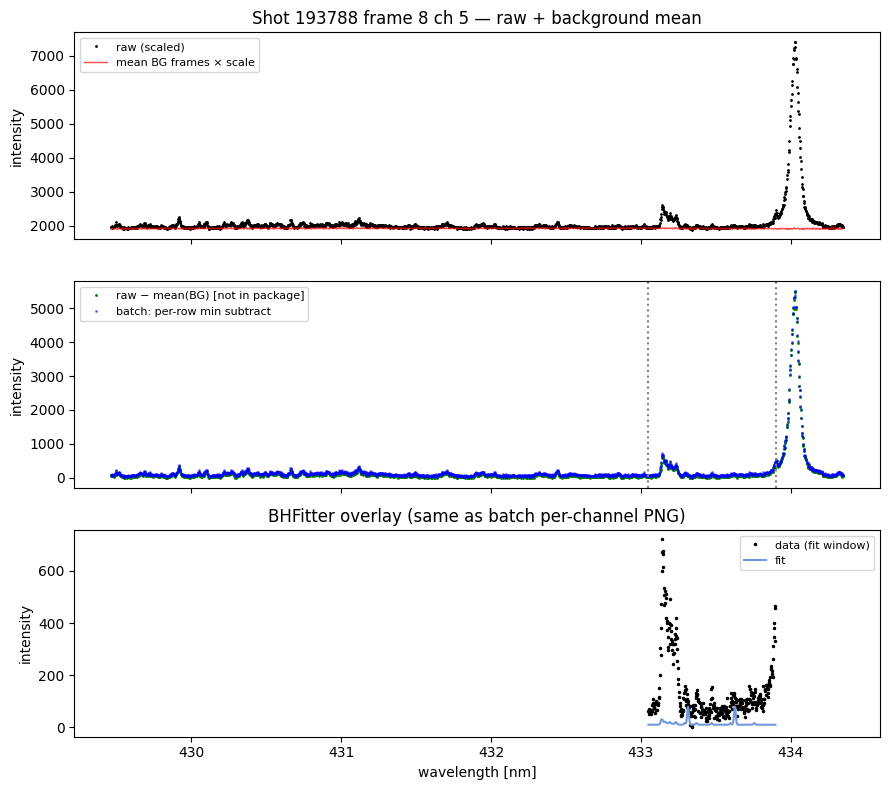

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(wl_raw, spec_raw, "k.", ms=2, label="raw (scaled)")
axes[0].plot(wl_raw, bg_row * SCALE, "r-", lw=1, alpha=0.7, label="mean BG frames × scale")
axes[0].set_ylabel("intensity")
axes[0].legend(fontsize=8)
axes[0].set_title(f"Shot {SHOT} frame {FRAME} ch {CHANNEL} — raw + background mean")

axes[1].plot(wl_raw, spec_bg_sub, "g.", ms=2, label="raw − mean(BG) [not in package]")
axes[1].plot(wl_raw, spec_fit, "b.", ms=2, alpha=0.5, label="batch: per-row min subtract")
axes[1].axvline(nm_lo, color="gray", ls=":")
axes[1].axvline(nm_hi, color="gray", ls=":")
axes[1].set_ylabel("intensity")
axes[1].legend(fontsize=8)

if ok:
    axes[2].plot(x, y, "k.", ms=3, label="data (fit window)")
    axes[2].plot(x, yfit, "-", color="#7397de", lw=1.5, label="fit")
    axes[2].set_xlabel("wavelength [nm]")
    axes[2].set_ylabel("intensity")
    axes[2].legend(fontsize=8)
    axes[2].set_title("BHFitter overlay (same as batch per-channel PNG)")

plt.tight_layout()
if SAVE_DEBUG_FIGURES:
    fig.savefig(DEBUG_OUT / "spectra_compare.png", dpi=150)
plt.show()

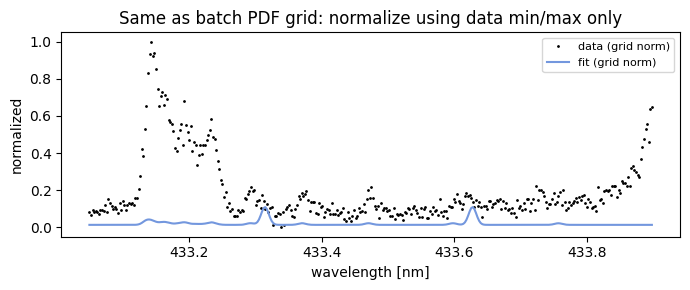

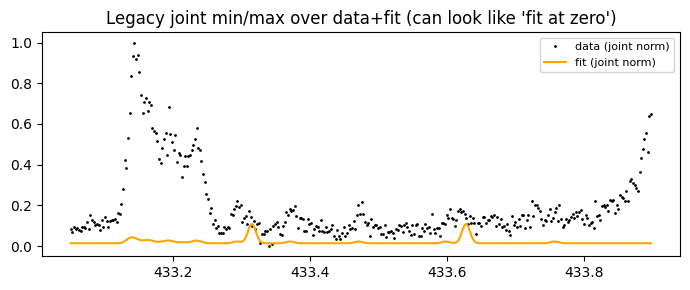

In [6]:
if ok:
    fig, ax = plt.subplots(figsize=(7, 3))
    y_n, yfit_n = normalize_curves_for_grid(y, yfit)
    ax.plot(x, y_n, "k.", ms=2, label="data (grid norm)")
    ax.plot(x, yfit_n, "-", color="#7397de", lw=1.5, label="fit (grid norm)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("wavelength [nm]")
    ax.set_ylabel("normalized")
    ax.set_title("Same as batch PDF grid: normalize using data min/max only")
    ax.legend(fontsize=8)
    plt.tight_layout()
    if SAVE_DEBUG_FIGURES:
        fig.savefig(DEBUG_OUT / "grid_norm_overlay.png", dpi=150)
    plt.show()

    # Old joint min/max (data+fit) — can pin a low-amplitude fit to ~0
    vmin = float(min(np.min(y), np.min(yfit)))
    vmax = float(max(np.max(y), np.max(yfit)))
    if vmax > vmin:
        y_joint = (y - vmin) / (vmax - vmin)
        yf_joint = (yfit - vmin) / (vmax - vmin)
    else:
        y_joint = np.zeros_like(y)
        yf_joint = np.zeros_like(yfit)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(x, y_joint, "k.", ms=2, label="data (joint norm)")
    ax.plot(x, yf_joint, "-", color="orange", lw=1.5, label="fit (joint norm)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("Legacy joint min/max over data+fit (can look like 'fit at zero')")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Summary checklist

- **Single path vs batch path:** If both use `prepare_vis_for_bh_batch` / same `CW_NM`, `SCALE`, `DARK_FRAME`, the `(wl, y)` passed to `BHFitter` is identical.
- **First divergence:** Any notebook that calls `spectrum(..., zero_min=False)` or skips `set_baseline_zero(True)` sees different `y` than batch.
- **Grid PDF:** Previously normalized using min/max over **both** data and fit; now uses **data-only** range (`normalize_curves_for_grid`). Compare the last two plots above.
- **Optional improvement:** Subtract `mean_background_spectrum` yourself if physics requires it; not currently in `run_bh_batch`.